# Tutorial 6: Mixed Precision Quantization Search with Mase and Optuna

In this tutorial, we'll see how Mase can be integrated with Optuna, the popular hyperparameter optimization framework, to search for a Bert model optimized for sequence classification on the IMDb dataset. We'll take the Optuna-generated model and import it into Mase, then run the CompressionPipeline to prepare the model for edge deployment by quantizing and pruning its weights.

As we'll see, running Architecture Search with Mase/Optuna involves the following steps.

1. **Define the search space**: this is a dictionary containing the range of values for each parameter at each layer in the model.

2. **Write the model constructor**: this is a function which uses Optuna utilities to sample a model from the search space, and constructs the model using transformers from_config class method.

3. **Write the objective function**: this function calls on the model constructor defined in Step 2 and defines the training/evaluation setup for each search iteration.

4. **Go!** Choose an Optuna sampler, create a study and launch the search.

In [7]:
checkpoint = "prajjwal1/bert-tiny"
tokenizer_checkpoint = "bert-base-uncased"
dataset_name = "imdb"

## Importing the model

If you are starting from scratch, you can load the Bert checkpoint directly from HuggingFace.

In [8]:
from transformers import AutoModelForSequenceClassification

checkpoint = "prajjwal1/bert-tiny"
model = AutoModelForSequenceClassification.from_pretrained(checkpoint)
model.config.problem_type = "single_label_classification"

base_model = model

Some weights of BertForSequenceClassification were not initialized from the model checkpoint at prajjwal1/bert-tiny and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


If you have previously ran the tutorial on Neural Architecture Search (NAS), run the following cell to import the best model obtained from the search process.

In [ ]:
from pathlib import Path
import dill

with open(f"{Path.home()}/tutorial_5_best_model.pkl", "rb") as f:
    base_model = dill.load(f)

First, fetch the dataset using the `get_tokenized_dataset` utility.

In [9]:
from chop.tools import get_tokenized_dataset

dataset, tokenizer = get_tokenized_dataset(
    dataset=dataset_name,
    checkpoint=tokenizer_checkpoint,
    return_tokenizer=True,
)

INFO     Tokenizing dataset imdb with AutoTokenizer for bert-base-uncased.


## 1. Defining the Search Space

We'll start by defining a search space, i.e. enumerating the possible combinations of hyperparameters that Optuna can choose during search. We'll explore the following range of values for the model's hidden size, intermediate size, number of layers and number of heads.

In [ ]:
import torch
from chop.nn.quantized.modules.linear import (
    LinearInteger,
    LinearMinifloatIEEE,
    LinearLog,
    LinearBlockFP,
    LinearBlockLog,
    LinearBinary,
)

# LinearBlockMinifloat doesn't work with Mase
search_space = {
    "linear_layer_choices": [
        torch.nn.Linear,
        LinearInteger,
        LinearMinifloatIEEE,
        LinearBlockFP,
        LinearLog,
        LinearBlockLog,
        LinearBinary,
    ],
}

## 2. Writing a Model Constructor

We define the following function, which will get called in each iteration of the search process. The function is passed the `trial` argument, which is an Optuna object that comes with many functionalities - see the [Trial documentation](https://optuna.readthedocs.io/en/stable/reference/trial.html) for more details. Here, we use the `trial.suggest_categorical` function, which triggers the chosen sampler to choose a layer type. The suggested integer is the index into the search space for each parameter, which we defined in the previous cell.

In [11]:
from chop.tools.utils import deepsetattr
from copy import deepcopy


def construct_model(trial):
    trial_model = deepcopy(base_model)

    # Quantize layers according to optuna suggestions
    for name, layer in list(trial_model.named_modules()):
        if isinstance(layer, torch.nn.Linear):
            new_layer_cls = trial.suggest_categorical(
                f"{name}_type",
                search_space["linear_layer_choices"],
            )

            if new_layer_cls == torch.nn.Linear:
                continue

            config = {}

            if new_layer_cls == LinearInteger:
                w = trial.suggest_categorical(f"{name}_w", [8, 16, 32])
                f = trial.suggest_categorical(f"{name}_f", [2, 4, 8])

                if f >= w:
                    f = w - 2

                config = {
                    "data_in_width": w,
                    "data_in_frac_width": f,
                    "weight_width": w,
                    "weight_frac_width": f,
                    "bias_width": w,
                    "bias_frac_width": f,
                }

            elif new_layer_cls == LinearMinifloatIEEE:
                exp_width = trial.suggest_categorical(f"{name}_exp", [3, 4, 5])
                man_width = trial.suggest_categorical(f"{name}_man", [2, 3, 4])

                # Total width = 1 (sign) + exponent_width + mantissa_width
                total_width = 1 + exp_width + man_width

                # Exponent bias is typically 2^(exp_width-1) - 1 thanks to IEEE
                exp_bias = (2 ** (exp_width - 1)) - 1

                config = {
                    # Data input config
                    "data_in_width": total_width,
                    "data_in_exponent_width": exp_width,
                    "data_in_exponent_bias": exp_bias,
                    # Weight config
                    "weight_width": total_width,
                    "weight_exponent_width": exp_width,
                    "weight_exponent_bias": exp_bias,
                    # Bias config
                    "bias_width": total_width,
                    "bias_exponent_width": exp_width,
                    "bias_exponent_bias": exp_bias,
                }

            elif new_layer_cls == LinearBlockFP:
                w = trial.suggest_categorical(f"{name}_bfp_w", [8, 12, 16])
                exp_width = trial.suggest_categorical(f"{name}_bfp_exp", [4, 5, 8])
                block_size = trial.suggest_categorical(f"{name}_bfp_bs", [8, 16, 32])

                # Exponent bias for block FP
                exp_bias = (2 ** (exp_width - 1)) - 1

                config = {
                    # Data input config
                    "data_in_width": w,
                    "data_in_exponent_width": exp_width,
                    "data_in_exponent_bias": exp_bias,
                    "data_in_block_size": block_size,
                    # Weight config
                    "weight_width": w,
                    "weight_exponent_width": exp_width,
                    "weight_exponent_bias": exp_bias,
                    "weight_block_size": block_size,
                    # Bias config
                    "bias_width": w,
                    "bias_exponent_width": exp_width,
                    "bias_exponent_bias": exp_bias,
                    "bias_block_size": block_size,
                }

            elif new_layer_cls == LinearLog:
                w = trial.suggest_categorical(f"{name}_log_w", [4, 8])
                exp_bias = (2 ** (w - 1)) - 1

                config = {
                    "data_in_width": w,
                    "data_in_exponent_bias": exp_bias,
                    "weight_width": w,
                    "weight_exponent_bias": exp_bias,
                    "bias_width": w,
                    "bias_exponent_bias": exp_bias,
                }

            # LinearBlockLog uses exponent_bias_width (not exponent_bias!)
            elif new_layer_cls == LinearBlockLog:
                w = trial.suggest_categorical(f"{name}_blog_w", [4, 8])
                block_size = trial.suggest_categorical(f"{name}_blog_bs", [8, 16, 32])
                exp_bias_width = trial.suggest_categorical(
                    f"{name}_blog_ebw", [4, 5, 8]
                )

                config = {
                    "data_in_width": w,
                    "data_in_exponent_bias_width": exp_bias_width,
                    "data_in_block_size": [block_size],
                    "weight_width": w,
                    "weight_exponent_bias_width": exp_bias_width,
                    "weight_block_size": [block_size],
                    "bias_width": w,
                    "bias_exponent_bias_width": exp_bias_width,
                    "bias_block_size": [block_size],
                }

            elif new_layer_cls == LinearBinary:
                config = {
                    "weight_stochastic": False,
                    "data_in_stochastic": False,
                    "weight_bipolar": True,
                    "data_in_bipolar": False,
                }

            kwargs = {
                "in_features": layer.in_features,
                "out_features": layer.out_features,
                "config": config,
            }

            # handle bias
            if layer.bias is not None:
                kwargs["bias"] = True
            else:
                kwargs["bias"] = False

            new_layer = new_layer_cls(**kwargs)

            new_layer.weight.data = layer.weight.data.clone()
            if layer.bias is not None and new_layer.bias is not None:
                new_layer.bias.data = layer.bias.data.clone()

            deepsetattr(trial_model, name, new_layer)

    return trial_model

## 3. Defining the Objective Function

Next, we define the objective function for the search, which gets called on each trial. In each trial, we create a new model instace with chosen hyperparameters according to the defined sampler. We then use the `get_trainer` utility in Mase to run a training loop on the IMDb dataset for a number of epochs. Finally, we use `evaluate` to report back the classification accuracy on the test split.

In [ ]:
from chop.tools import get_trainer


def objective(trial):
    # Define the model
    model = construct_model(trial)

    trainer = get_trainer(
        model=model,
        tokenized_dataset=dataset,
        tokenizer=tokenizer,
        evaluate_metric="accuracy",
        num_train_epochs=1,
    )
    print(f"Trial {trial.number} model is on: {model.device}")

    trainer.train()
    eval_results = trainer.evaluate()

    trial.set_user_attr("model", model)

    return eval_results["eval_accuracy"]

## 4. Launching the Search

Optuna provides a number of samplers, for example:

* **GridSampler**: iterates through every possible combination of hyperparameters in the search space
* **RandomSampler**: chooses a random combination of hyperparameters in each iteration
* **TPESampler**: uses Tree-structured Parzen Estimator algorithm to choose hyperparameter values.

You can define the chosen sampler by simply importing from `optuna.samplers` as below.

In [13]:
from optuna.samplers import RandomSampler

sampler = RandomSampler()

With all the pieces in place, we can launch the search as follows. The number of trials is set to 1 so you can go get a coffee for 10 minutes, then proceed with the tutorial. However, this will essentially be a random model - for better results, set this to 100 and leave it running overnight!

In [ ]:
import optuna
import warnings

# Stop the spam plz ty
warnings.filterwarnings("ignore")
optuna.logging.set_verbosity(optuna.logging.ERROR)

study = optuna.create_study(
    direction="maximize",
    study_name="bert-tiny-nas-study-v2",
    sampler=sampler,
)

N_TRIALS = 50

study.optimize(
    objective,
    n_trials=N_TRIALS,
    timeout=60 * 60 * 3,  # 3 hour timeout
    show_progress_bar=True,
)

  0%|          | 0/50 [00:00<?, ?it/s]

Trial 0 Model is on: cuda:0


Step,Training Loss
500,0.643100
1000,0.492400
1500,0.443600
2000,0.407600
2500,0.390600
3000,0.381200


Best trial: 0. Best value: 0.84968:   2%|▏         | 1/50 [02:38<2:09:47, 158.93s/it, 158.92/86400 seconds]

Trial 1 Model is on: cuda:0


...

Step,Training Loss
500,0.665300
1000,0.517800
1500,0.470500
2000,0.422900
2500,0.406500
3000,0.401500


Best trial: 40. Best value: 0.85792:  98%|█████████▊| 49/50 [2:15:57<02:49, 169.00s/it, 8157.69/86400 seconds]

Trial 49 Model is on: cuda:0


Step,Training Loss
500,1.726200
1000,1.259500
1500,0.952000
2000,0.817000
2500,0.671100
3000,0.657500


Best trial: 40. Best value: 0.85792: 100%|██████████| 50/50 [2:18:32<00:00, 166.26s/it, 8312.88/86400 seconds]


## 5. Plotting Results

### Task 1: Maximum accuracy vs. number of trials

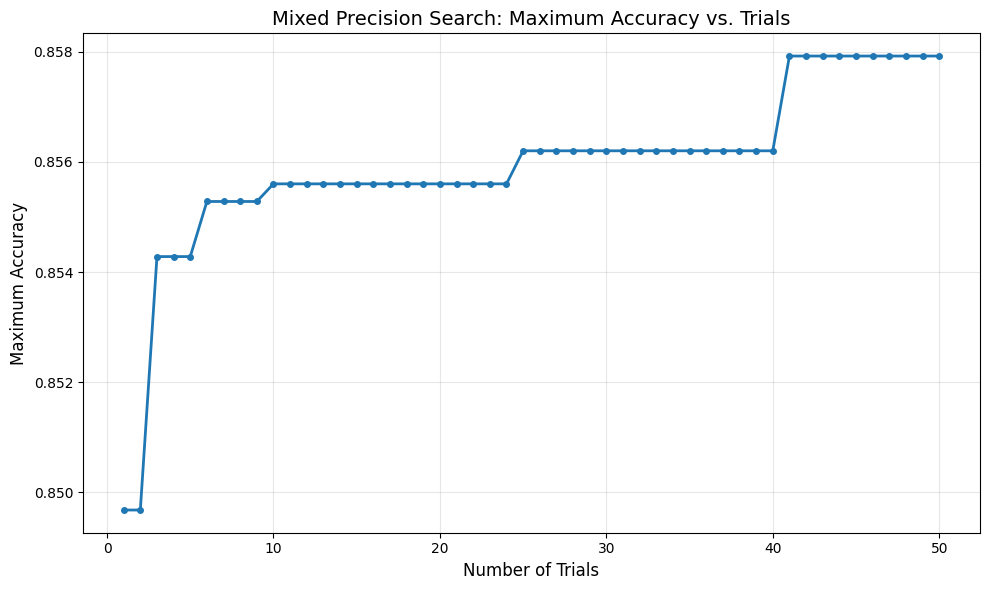

Best accuracy: 0.8579
Best trial: 40


In [15]:
import matplotlib.pyplot as plt
import numpy as np

trials = study.trials
accuracies = [t.value for t in trials if t.value is not None]

# Calc the running maximum
running_max = np.maximum.accumulate(accuracies)

plt.figure(figsize=(10, 6))
plt.plot(
    range(1, len(running_max) + 1), running_max, marker="o", linewidth=2, markersize=4
)
plt.xlabel("Number of Trials", fontsize=12)
plt.ylabel("Maximum Accuracy", fontsize=12)
plt.title("Mixed Precision Search: Maximum Accuracy vs. Trials", fontsize=14)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig("task1_accuracy_vs_trials.png", dpi=150)
plt.show()

print(f"Best accuracy: {study.best_value:.4f}")
print(f"Best trial: {study.best_trial.number}")

### Task 2: Plot accuracy curves by precision type

This analyses which layer types perform best.

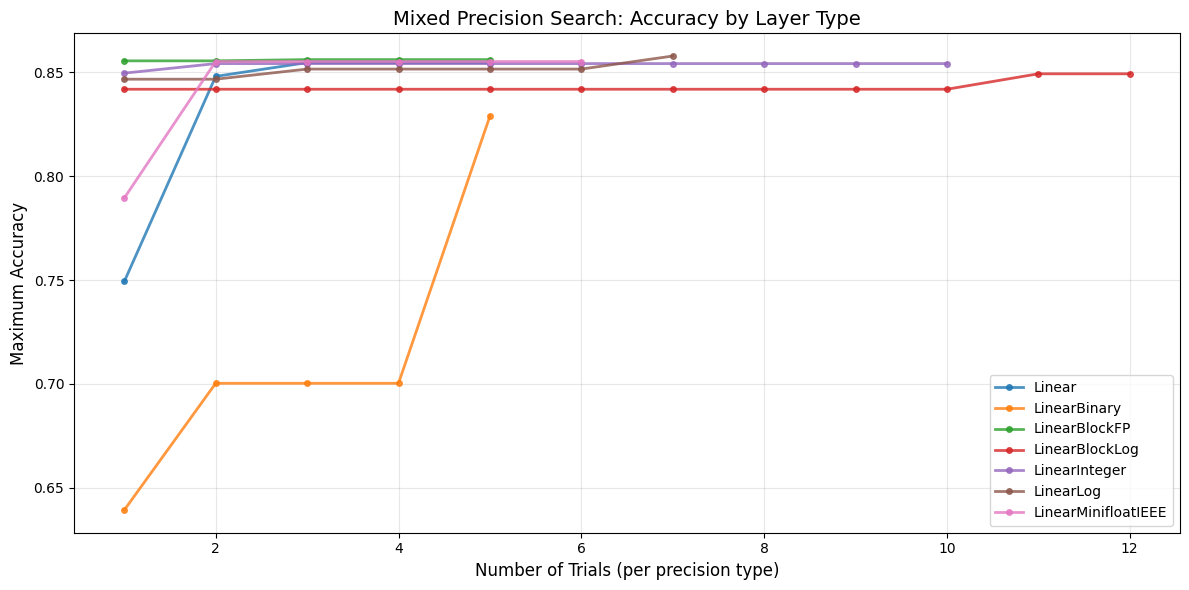


Summary by Precision Type:
--------------------------------------------------
Linear:
  Trials: 5
  Best: 0.8548
  Mean: 0.7557

LinearBinary:
  Trials: 5
  Best: 0.8290
  Mean: 0.6946

LinearBlockFP:
  Trials: 5
  Best: 0.8562
  Mean: 0.8163

LinearBlockLog:
  Trials: 12
  Best: 0.8494
  Mean: 0.7936

LinearInteger:
  Trials: 10
  Best: 0.8543
  Mean: 0.7983

LinearLog:
  Trials: 7
  Best: 0.8579
  Mean: 0.8359

LinearMinifloatIEEE:
  Trials: 6
  Best: 0.8553
  Mean: 0.8000



In [ ]:
# Analyse trials by dominant layer type
from collections import defaultdict

precision_results = defaultdict(list)

for trial in study.trials:
    if trial.value is None:
        continue

    # Count layer types used in this trial
    layer_counts = defaultdict(int)
    for param_name, param_value in trial.params.items():
        if param_name.endswith("_type"):
            # Get the class name
            if hasattr(param_value, "__name__"):
                layer_name = param_value.__name__
            else:
                layer_name = str(param_value)
            layer_counts[layer_name] += 1

    # Find the dominant (most common) layer type
    if layer_counts:
        dominant_type = max(layer_counts.keys(), key=lambda k: layer_counts[k])
        precision_results[dominant_type].append((trial.number, trial.value))

# Plot
plt.figure(figsize=(12, 6))

colors = plt.cm.tab10.colors
for idx, (precision_type, results) in enumerate(sorted(precision_results.items())):
    if not results:
        continue

    # Sort by trial number
    results_sorted = sorted(results, key=lambda x: x[0])
    trial_nums = [r[0] for r in results_sorted]
    accuracies = [r[1] for r in results_sorted]

    # Calculate running max for this precision type
    running_max = np.maximum.accumulate(accuracies)

    plt.plot(
        range(1, len(running_max) + 1),
        running_max,
        marker="o",
        label=precision_type,
        color=colors[idx % len(colors)],
        linewidth=2,
        markersize=4,
        alpha=0.8,
    )

plt.xlabel("Number of Trials (per precision type)", fontsize=12)
plt.ylabel("Maximum Accuracy", fontsize=12)
plt.title("Mixed Precision Search: Accuracy by Layer Type", fontsize=14)
plt.legend(loc="lower right", fontsize=10)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig("task2_accuracy_by_precision.png", dpi=150)
plt.show()

# Print summary statistics
print("\nSummary by Precision Type:")
print("-" * 50)
for precision_type, results in sorted(precision_results.items()):
    accs = [r[1] for r in results]
    print(f"{precision_type}:")
    print(f"  Trials: {len(results)}")
    print(f"  Best: {max(accs):.4f}")
    print(f" Mean: {np.mean(accs):.4f}")
    print()

## 6. Best Model Summary

In [17]:
print("Best Trial Configuration:")
print("=" * 60)
print(f"Trial Number: {study.best_trial.number}")
print(f"Accuracy: {study.best_value:.4f}")
print("\nLayer Configurations:")

for param_name, param_value in sorted(study.best_trial.params.items()):
    if hasattr(param_value, "__name__"):
        print(f"  {param_name}: {param_value.__name__}")
    else:
        print(f"  {param_name}: {param_value}")

Best Trial Configuration:
Trial Number: 40
Accuracy: 0.8579

Layer Configurations:
  bert.encoder.layer.0.attention.output.dense_type: LinearBinary
  bert.encoder.layer.0.attention.self.key_type: Linear
  bert.encoder.layer.0.attention.self.query_exp: 4
  bert.encoder.layer.0.attention.self.query_man: 4
  bert.encoder.layer.0.attention.self.query_type: LinearMinifloatIEEE
  bert.encoder.layer.0.attention.self.value_f: 2
  bert.encoder.layer.0.attention.self.value_type: LinearInteger
  bert.encoder.layer.0.attention.self.value_w: 16
  bert.encoder.layer.0.intermediate.dense_log_w: 8
  bert.encoder.layer.0.intermediate.dense_type: LinearLog
  bert.encoder.layer.0.output.dense_log_w: 4
  bert.encoder.layer.0.output.dense_type: LinearLog
  bert.encoder.layer.1.attention.output.dense_f: 4
  bert.encoder.layer.1.attention.output.dense_type: LinearInteger
  bert.encoder.layer.1.attention.output.dense_w: 32
  bert.encoder.layer.1.attention.self.key_log_w: 4
  bert.encoder.layer.1.attention.sel